# Robotics, Vision & Control 3e: for Python
## Chapter 6: Localization and Mapping

Copyright (c) 2021- Peter Corke

In [1]:
try:
    import google.colab
    print('Running on CoLab')
    COLAB = True
    #!pip install roboticstoolbox-python>=1.0.2
    !pip install git+https://github.com/petercorke/robotics-toolbox-python@future
    !pip install spatialmath-python>=1.1.5
    !pip install --no-deps rvc3python
except ModuleNotFoundError:
    COLAB = False

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr_or_assign"
from IPython.display import HTML

import matplotlib.pyplot as plt

# add RTB examples folder to the path
import sys, os.path
import RVC3 as rvc
sys.path.append(os.path.join(rvc.__path__[0], 'models'))

# ------ standard imports ------ #
%matplotlib widget 
import numpy as np
import math
from math import pi
np.set_printoptions(
    linewidth=120, formatter={
        'float': lambda x: f"{0:8.4g}" if abs(x) < 1e-10 else f"{x:8.4g}"})
np.random.seed(0)
from spatialmath import *
from spatialmath.base import *
from roboticstoolbox import *

There are some minor code changes compared to the book. These are to support 
animations in the Jupyter environment. Animations can be made using `FuncAnimation` and
the `widget` backend, but with Colab these can be very unsmooth.  Instead we render the 
animations to HTML5 and render them locally in the browser.

# 6.1 Dead Reckoning using Odometry


## 6.1.1 Modeling the Robot


In [2]:
V = np.diag([0.02, np.deg2rad(0.5)]) ** 2; # matriz covarianza ruido sensores en odometria 

In [3]:
robot = Bicycle(covar=V, animation="car")

Bicycle: x = [ 0, 0, 0 ]
  L=1, steer_max=1.41372, speed_max=inf, accel_max=inf

In [4]:
odo = robot.step((1, 0.3)) # lineal vwelocity and angle direction 

array([  0.1025,  0.02978])

In [5]:
robot.q # representa posicion y orientación, coordenadas y orientación  ern radianes 

array([     0.1,        0,  0.03093])

In [6]:
robot.f([0, 0, 0], odo)  # f is a trasnlaction function 

array([  0.1025,        0,  0.02978])

In [7]:
robot.control = RandomPath(workspace=10)

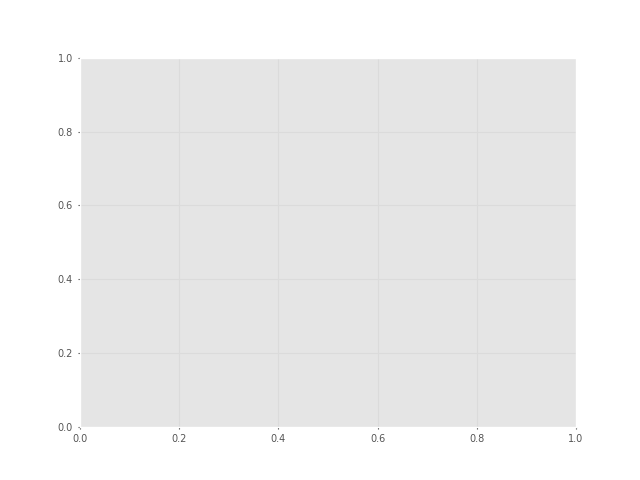

In [8]:
#robot.run(T=10.5);

#html = robot.run_animation(T=2)

robot.run_animation(T=30) 



## 6.1.2 Estimating Pose


In [ ]:
robot.Fx([0, 0, 0], [0.5, 0.1])   # Jacobiano de la función de movimiento del robot,
# es decir, la derivada de la función de movimiento respecto a la posición y orientación del robot

array([[       1,        0,        0],
       [       0,        1,      0.5],
       [       0,        0,        1]])

In [10]:
x_sdev = [0.05, 0.05, np.deg2rad(0.5)];# covaraianza de estado inicial
P0 = np.diag(x_sdev) ** 2; # matriz inicial del filtro de Kalman 

In [11]:
# now create a extender version of kalman filter
ekf = EKF(robot=(robot, V), P0=P0)

EKF object: 3 states, estimating: vehicle pose, map
  robot: Bicycle: x = [ 0, 0, 0 ]
    L=1, steer_max=1.41372, speed_max=inf, accel_max=inf
  V_est:  [ 0.0004, 0 | 0, 7.62e-05 ]

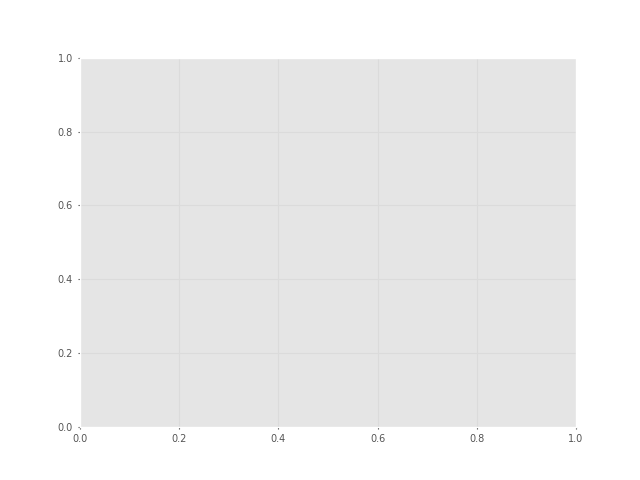

In [12]:
# ekf.run(T=20);

#html = ekf.run_animation(T=20) 
ekf.run_animation(T=30) 

In [ ]:
robot.plot_xy(color="b") #  trayectoria real 
ekf.plot_xy(color="r") # estimada usando Kalman 

In [14]:
P150 = ekf.get_P(150)

array([[  0.1666, -0.04335,  0.03476],
       [-0.04335,  0.09977, -0.01525],
       [ 0.03476, -0.01525,  0.01158]])

In [18]:
np.sqrt(P150[0, 0]) # desviacion estandar de la posición x estimada
 #  68% de probabilidad de que la posición real en x esté dentro de ±0.41 metros de la estimada

0.4081316906810882

In [17]:
np.sqrt(P150[1, 1]) # desviacion estandar de la posición y

0.3158704661243764

In [16]:
ekf.plot_xy(color="r")
ekf.plot_ellipse(filled=True, facecolor="g", alpha=0.3)

In [19]:
t = ekf.get_t(); # tiempos de cada paso 
pn = ekf.get_Pnorm(); # norma de la matriz de cov (medida generla de incertidumbre)
plt.plot(t, pn); # filtro convergetne o tiene problemas

# 6.2 Localizing with a Landmark Map


In [20]:
map = LandmarkMap(20, workspace=10)

LandmarkMap object with 20 landmarks, workspace=(-10.0: 10.0, -10.0: 10.0)

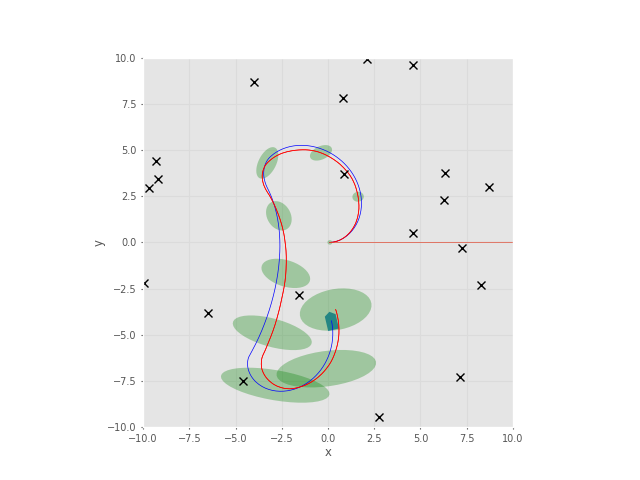

In [ ]:
map.plot() # plot he landmark map 
plt.show()

In [22]:
W = np.diag([0.1, np.deg2rad(1)]) ** 2;

In [23]:
sensor = RangeBearingSensor(robot=robot, map=map, covar=W,  
           angle=[-pi/2, pi/2], range=4)



RangeBearingSensor sensor class
  LandmarkMap object with 20 landmarks, workspace=(-10.0: 10.0, -10.0: 10.0)
  W = [ 0.01, 0 | 0, 0.000305 ]
  sampled every 1 samples
  range: (0: 4)
  angle: (-1.57: 1.57)

In [24]:
ekf = EKF(robot=(robot, V), P0=P0, map=map, sensor=(sensor, W));

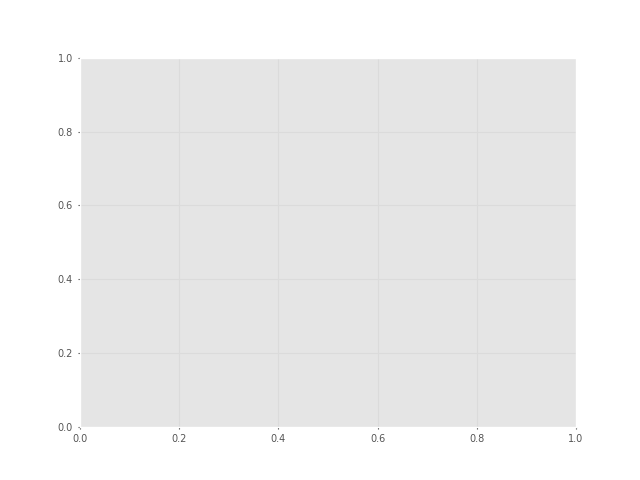

In [25]:
ekf.run_animation(T=30)

In [26]:
z, i = sensor.reading() # usefull to kalman filter 
# z
# i
print(f"landmark {i} at {z}")

landmark 19 at [   2.148   0.6537]


In [ ]:
map[15] ## see the reference position 

array([  -6.487,   -3.795])

In [ ]:
map[10]

array([   6.317,    3.769])

In [29]:
map = LandmarkMap(40, workspace=10); # upgrade the numbers of landmarks
V = np.diag([0.02, np.deg2rad(0.5)]) ** 2
robot = Bicycle(covar=V, animation="car");
robot.control = RandomPath(workspace=map, seed=0)
W = np.diag([0.1, np.deg2rad(1)]) ** 2
sensor = RangeBearingSensor(robot=robot, map=map, covar=W, 
           angle=[-pi/2, pi/2], range=4, seed=0)
P0 = np.diag([0.05, 0.05, np.deg2rad(0.5)]) ** 2;
ekf = EKF(robot=(robot, V), P0=P0, map=map, sensor=(sensor, W));

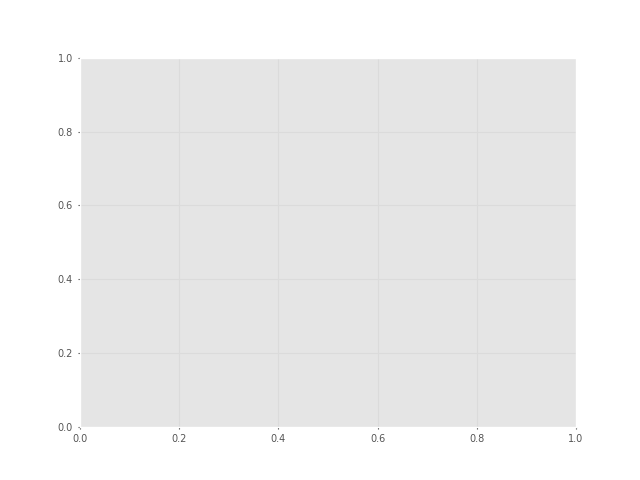

In [30]:
# ekf.run(T=20)
#html = ekf.run_animation(T=20)
ekf.run_animation(T=30)

In [31]:
map.plot()
robot.plot_xy();
ekf.plot_xy();
ekf.plot_ellipse()

# 6.3 Creating a Landmark Map


In [32]:
map = LandmarkMap(50, workspace=15, seed=3);
robot = Bicycle(covar=V, animation="car");
robot.control = RandomPath(workspace=map);
W = np.diag([0.1, np.deg2rad(1)]) ** 2
sensor = RangeBearingSensor(robot=robot, map=map, covar=W, 
           range=4, angle=[-pi/2, pi/2]);
ekf = EKF(robot=(robot, None), sensor=(sensor, W));

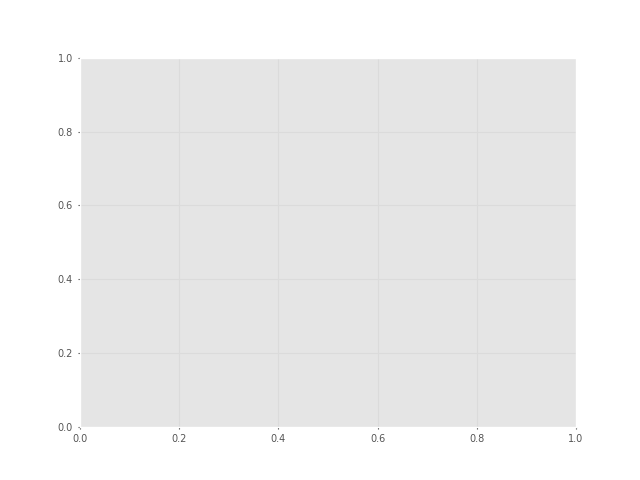

In [33]:
ekf.run_animation(T=100)

In [ ]:
# ekf.run(T=100);

#html = ekf.run_animation(T=100, format="html")
#HTML(html)

In [34]:
map.plot();
ekf.plot_map();
robot.plot_xy();

In [39]:
ekf.landmark(2) #  see how the landmark 2 is estimated 

(14, 13)

In [40]:
ekf.x_est[24:26]

array([   7.133,    12.64])

In [ ]:
ekf.P_est[24:26, 24:26] # print estimate position at this landmarks 

array([[2.727e-05, 1.798e-05],
       [1.798e-05, 1.929e-05]])

# 6.4 Simultaneous Localization and Mapping


In [42]:
map = LandmarkMap(20, workspace=10);
W = np.diag([0.1, np.deg2rad(1)]) ** 2 
robot = Bicycle(covar=V, x0=(3, 6, np.deg2rad(-45)), 
          animation="car");
robot.control = RandomPath(workspace=map);
W = np.diag([0.1, np.deg2rad(1)]) ** 2
sensor = RangeBearingSensor(robot=robot, map=map, covar=W, 
           range=4, angle=[-pi/2, pi/2], animate=True);
P0 = np.diag([0.05, 0.05, np.deg2rad(0.5)]) ** 2;
ekf = EKF(robot=(robot, V), P0=P0, sensor=(sensor, W));

TypeError: SensorBase.__init__() got an unexpected keyword argument 'animate'

In [ ]:
# ekf.run(T=40);
ekf.run_animation(T=40) 

#html = ekf.run_animation(T=40, format="html")
#HTML(html)

In [ ]:
map.plot();       # plot true map
robot.plot_xy();  # plot true path

In [ ]:
ekf.plot_map();      # plot estimated landmark position
ekf.plot_ellipse();  # plot estimated covariance
ekf.plot_xy();       # plot estimated robot path

In [ ]:
T = ekf.get_transform(map)

# 6.5 Pose-Graph SLAM


NOTE. Minor changes to ensure Jupyter pretty printing of SymPy equations.  Introduced underscore to indicate subscripting, and changed `t` to `theta`
which is printed as $\theta$.

In [ ]:
import sympy
xi, yi, ti, xj, yj, tj = sympy.symbols("x_i y_i theta_i x_j y_j theta_j")
xm, ym, tm = sympy.symbols("x_m y_m theta_m")
xi_e = SE2(xm, ym, tm).inv() * SE2(xi, yi, ti).inv() \
     * SE2(xj, yj, tj);
fk = sympy.Matrix(sympy.simplify(xi_e.xyt()));

In [ ]:
Ai = sympy.simplify(fk.jacobian([xi, yi, ti]))
Ai.shape

In [ ]:
Ai

In [ ]:
pg = PoseGraph("data/pg1.g2o");

In [ ]:
pg.plot();

In [ ]:
# pg.optimize(animate=True)

pg.optimize(animate=False)
pg.plot()

In [ ]:
pg = PoseGraph("data/killian-small.toro");

In [ ]:
pg.plot(text=False)

In [ ]:
pg.optimize()
pg.plot(text=False)

# 6.6 Sequential Monte-Carlo Localization


In [ ]:
map = LandmarkMap(20, workspace=10);

In [ ]:
V = np.diag([0.02, np.deg2rad(0.5)]) ** 2;
robot = Bicycle(covar=V, animation="car", workspace=map);
robot.control = RandomPath(workspace=map)

In [ ]:
W = np.diag([0.1, np.deg2rad(1)]) ** 2;
sensor = RangeBearingSensor(robot, map, covar=W, plot=True);

In [ ]:
R = np.diag([0.1, 0.1, np.deg2rad(1)]) ** 2;

In [ ]:
L = np.diag([0.1, 0.1]);

In [ ]:
pf = ParticleFilter(robot, sensor=sensor, R=R, L=L, nparticles=1000, animate=True);

In [ ]:
# pf.run(T=10);

html = pf.run_animation(T=10, format="html");
HTML(html)

In [ ]:
map.plot();
robot.plot_xy();

In [ ]:
pf.plot_xy();

In [ ]:
plt.plot(pf.get_std()[:100,:]);

In [ ]:
pf.plot_pdf()

# 6.8 Application: Lidar


## 6.8.1 Lidar-based Odometry


In [ ]:
pg = PoseGraph("data/killian.g2o.zip", lidar=True);

In [ ]:
[r, theta] = pg.scan(100);
r.shape
theta.shape

In [ ]:
plt.clf()
plt.polar(theta, r);

In [ ]:
p100 = pg.scanxy(100);
p101 = pg.scanxy(100);
p100.shape

In [ ]:
T = pg.scanmatch(100, 101);
T.printline()

In [ ]:
pg.time(101) - pg.time(100)

## 6.8.2 Lidar-based Map Building


In [ ]:
og = OccupancyGrid(workspace=[-100, 250, -100, 250], cellsize=0.1, value=np.int32(0));
pg.scanmap(og, maxrange=40)
og.plot(cmap="gray")